In [2]:
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../output/data/data_4.csv')
df.columns = ['alpha', 'beta', 'value']

pivot_df = df.pivot(index='alpha', columns='beta', values='value')

pivot_df

beta,-0.500000,-0.489950,-0.479899,-0.469849,-0.459799,-0.449749,-0.439698,-0.429648,-0.419598,-0.409548,...,1.409548,1.419598,1.429648,1.439698,1.449749,1.459799,1.469849,1.479899,1.489950,1.500000
alpha,,,,,,,,,,,,,,,,,,,,,
-0.500000,NaN,40.866669,41.600002,42.400002,43.066669,44.466667,47.133335,49.266670,53.066669,53.800003,...,159.933334,162.133347,165.466675,170.266678,173.800003,178.600006,184.133347,189.600006,197.400009,208.533340
-0.489950,39.666668,40.133335,40.866669,42.266670,43.066669,43.866669,45.400002,48.000004,51.266670,53.533337,...,159.800003,162.466675,166.866669,170.066681,174.466675,179.400009,185.133347,190.466675,197.333344,209.400009
-0.479899,39.533337,40.000004,40.733334,41.200001,42.733337,43.200001,44.933334,46.000004,50.200001,51.066669,...,159.466675,162.333344,166.933350,170.800003,174.800003,179.066681,185.133347,191.133347,198.733337,209.466675
-0.469849,39.533337,39.333336,40.466667,41.466667,42.333336,43.200001,44.200001,45.866669,47.600002,50.600002,...,159.800003,163.533340,167.133347,171.200012,175.266678,179.466675,185.866684,191.600006,199.733337,210.066681
-0.459799,39.133335,39.333336,39.800003,41.200001,42.000004,42.600002,43.800003,45.600002,47.533337,50.200001,...,159.600006,163.666672,167.800003,172.000015,175.400009,179.933350,186.133347,193.200012,200.600006,210.333344
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1.459799,12.733334,12.733334,12.733334,12.733334,12.733334,12.800001,12.800001,12.800001,12.800001,12.800001,...,115.400009,115.200005,114.533340,114.733337,114.933342,114.800003,114.733337,114.666672,115.133339,115.800003
1.469849,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.800001,12.800001,...,113.733337,113.466675,113.466675,114.000008,114.133339,114.066673,113.733337,114.000008,114.133339,115.200005
1.479899,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,12.733334,...,111.066673,112.066673,112.266670,112.666672,112.533340,113.066673,113.400009,113.533340,112.800003,114.000008


In [54]:
import matplotlib.pyplot as plt

def plot(data, out_path):
    fig, ax = plt.subplots()
    im = ax.imshow(data, vmin=0, vmax=500)

    # --- NEW: Add heatmap legend (colorbar) ---
    fig.colorbar(im, ax=ax)

    # --- NEW: Remove axis values ---
    # ax.set_xticks([0, 49, 99, 149, 199], labels=["-0.5", "0", "0.5", "1", "1.5"])
    # ax.set_yticks([0, 49, 99, 149, 199], labels=["-0.5", "0", "0.5", "1", "1.5"])
    ax.set_yticks([], labels=[])
    ax.set_xticks([], labels=[])

    label_data = [
        (50, 50, r'$\theta_{1}$'),   # (x, y, LaTeX string)
        (150, 50, r'$\theta_{2}$'),
        (150, 150, r'$\theta_{3}$'),
    ]

    # 1. Extract coordinates AND add the first point to the end to close the loop
    x_coords = [point[0] for point in label_data] + [label_data[0][0]]
    y_coords = [point[1] for point in label_data] + [label_data[0][1]]

    # 2. Draw the dashed red line connecting 1 -> 2 -> 3 -> 1
    ax.plot(
        x_coords, y_coords,
        color='red',
        linestyle='--',
        linewidth=2
    )

    # 3. Loop through and place the text labels on top
    for x, y, label in label_data:
        ax.text(
            x, y, label,
            color='white',
            fontsize=14,
            ha='center',
            va='center',
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='black',
                edgecolor='none',
                alpha=0.6
            )
        )

    plt.show()
    fig.savefig(out_path)

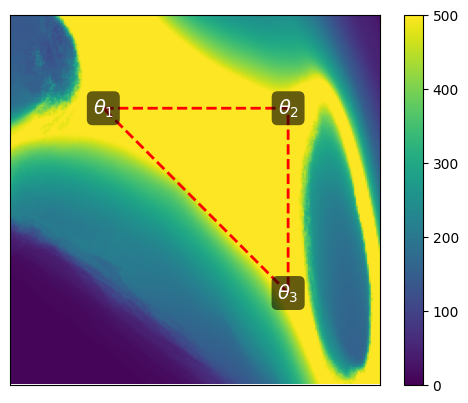

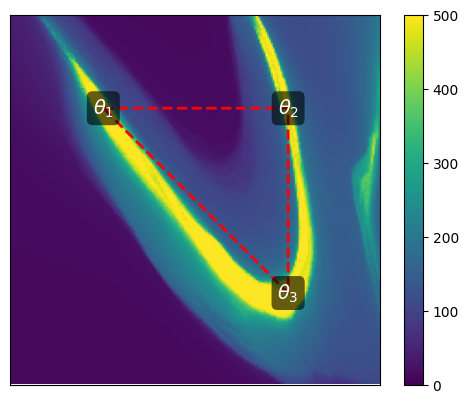

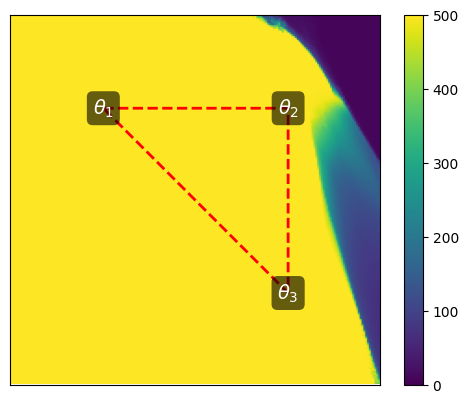

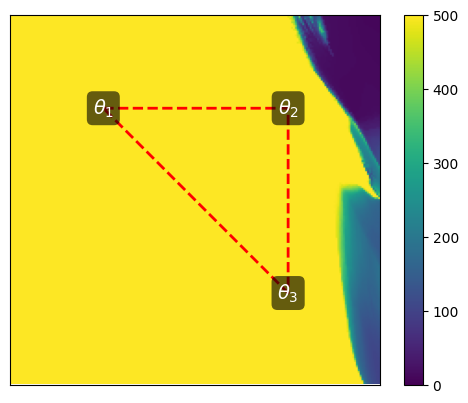

In [55]:
for s in [3, 4]:
    df = pd.read_csv(f'../output/linear_interpolation/dqn_cp_bc/data_{s}.csv')
    df.columns = ['alpha', 'beta', 'value']
    pivot_df = df.pivot(index='alpha', columns='beta', values='value')

    plot(pivot_df, f'heatmap_dqn_s{s}.svg')


for s in [3, 4]:
    df = pd.read_csv(f'../output/linear_interpolation/sacd_ji_ent_1/data_{s}.csv')
    df.columns = ['alpha', 'beta', 'value']
    pivot_df = df.pivot(index='alpha', columns='beta', values='value')


    plot(pivot_df, f'heatmap_sacd_s{s}.svg')

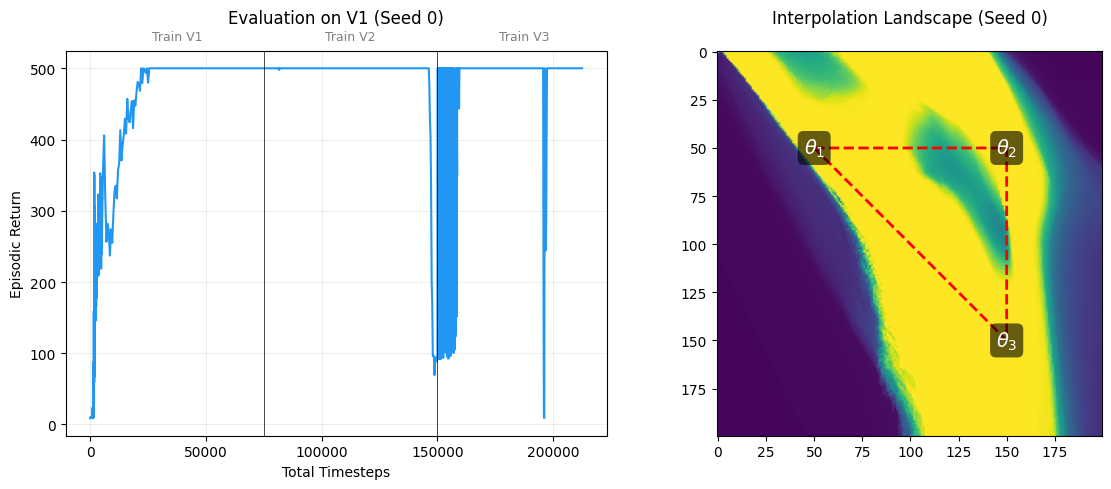

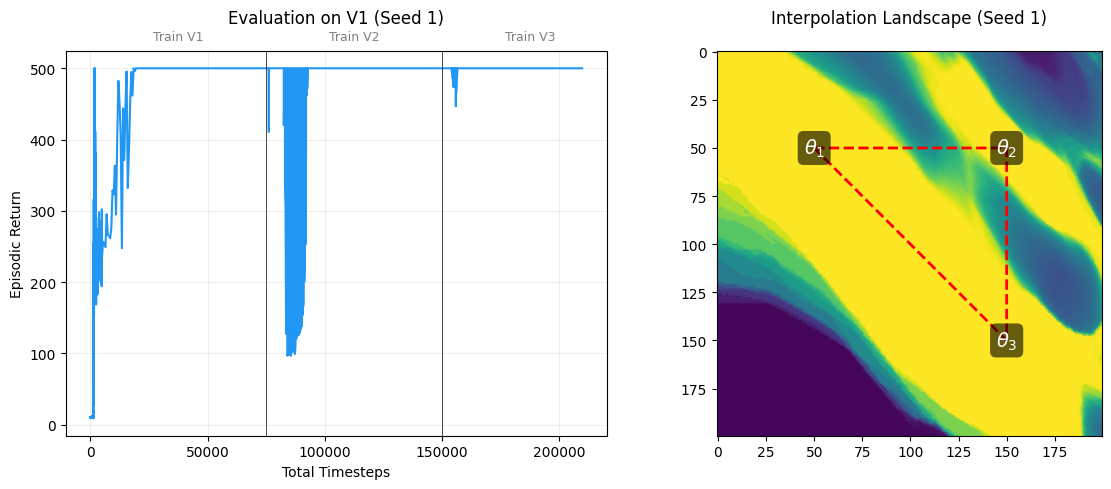

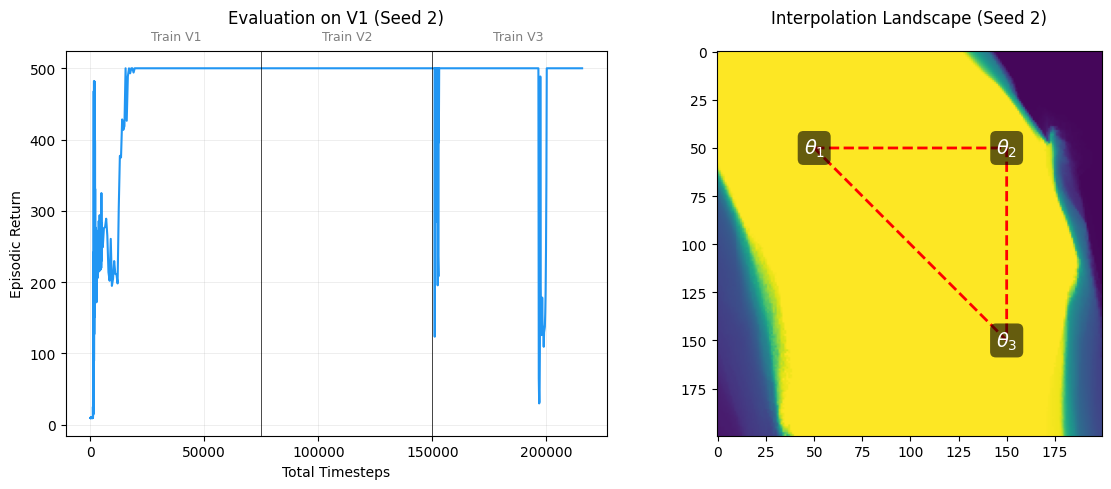

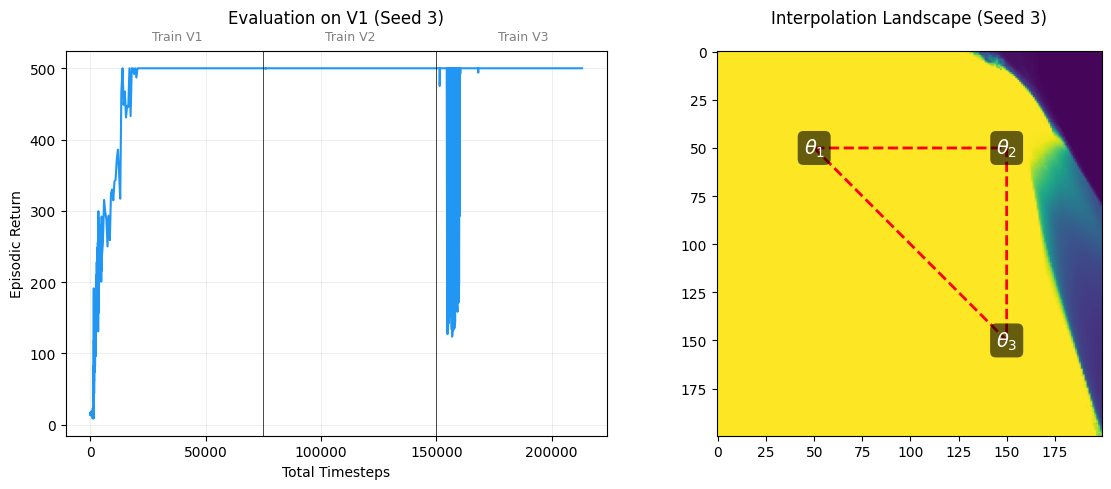

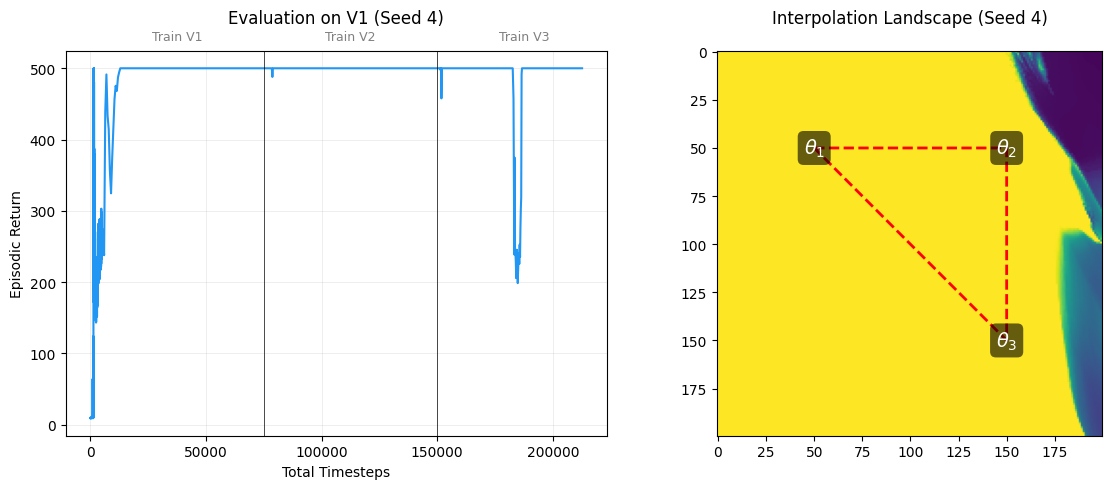

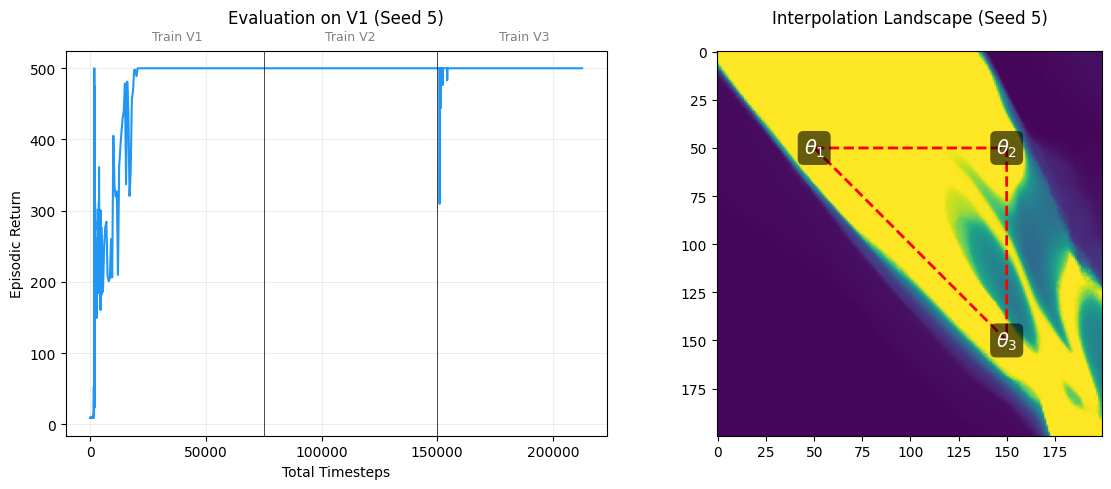

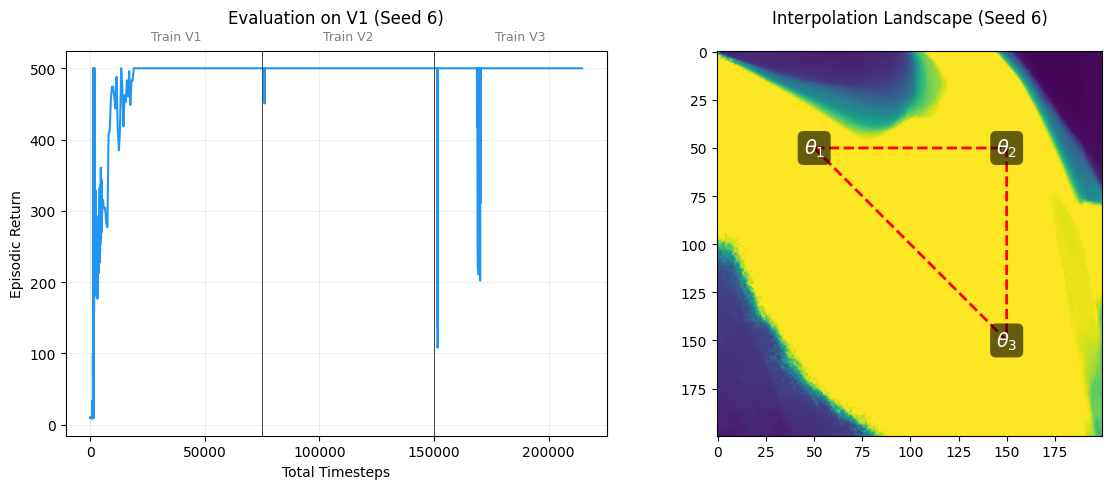

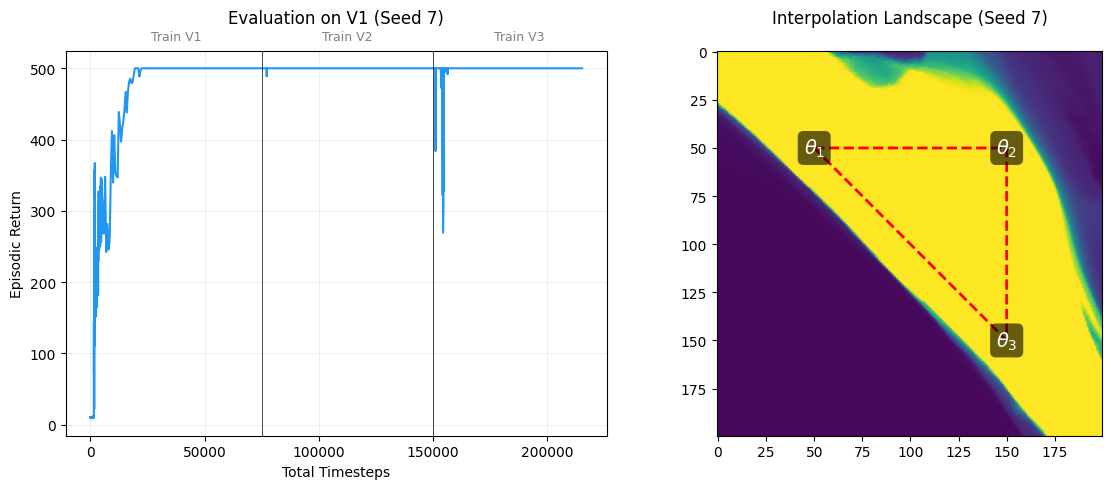

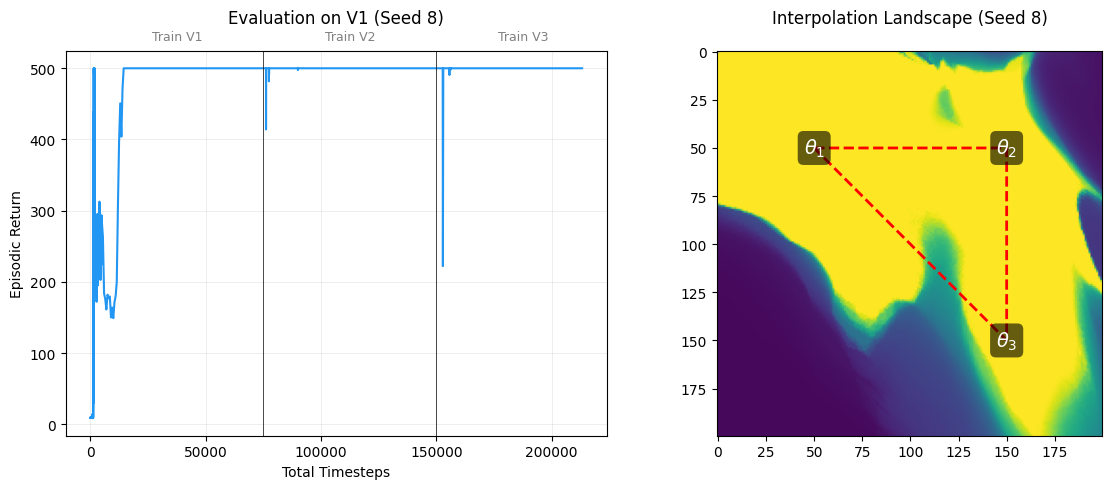

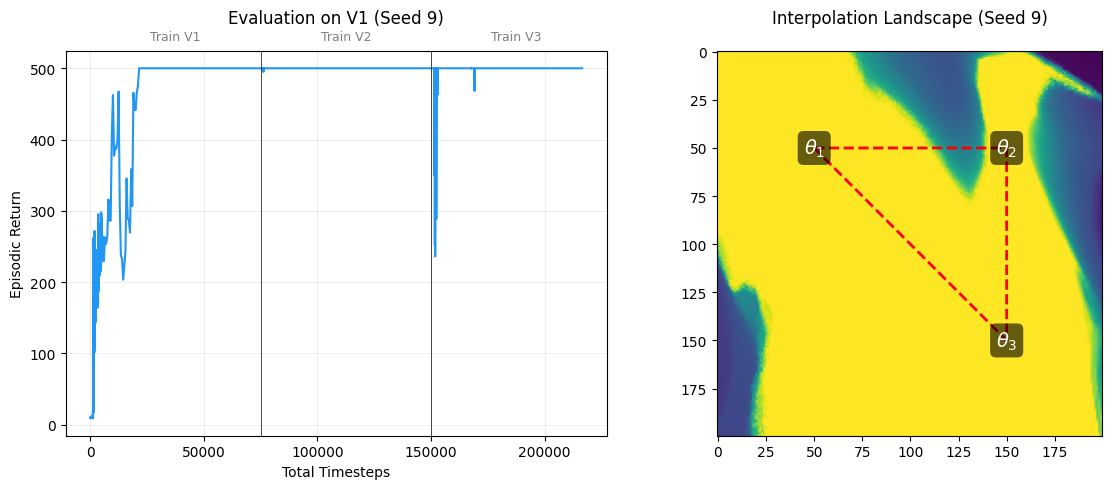

In [7]:
from plot_iqm import load_eval_data  # Imports the data loader from your script

def plot_seed_comparisons(
    seeds: list[int],
    method: str,
    test_env: str,
    heatmap_path_template: str,
    train_envs: list[str] = ["V1", "V2", "V3"],
    timesteps_per_env: int = 75_000
):
    """
    For each seed, generates a 1x2 plot:
    Left: The training/eval curve for that specific seed (styled like plot_iqm).
    Right: The interpolation heatmap with the red dashed triangle.

    heatmap_path_template: e.g., '../output/data/data_{seed}.csv'
    """

    for seed in seeds:
        # Create a side-by-side figure (12 inches wide, 5 inches tall)
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

        # ==========================================
        # 1. LEFT PLOT: Evaluation Curve
        # ==========================================
        # Load the curve data for this specific seed
        df_eval = load_eval_data(
            method=method,
            seed=seed,
            test_env=test_env,
            train_envs=train_envs,
            timesteps_per_env=timesteps_per_env
        )

        if not df_eval.empty:
            ax1.plot(df_eval["timestep"], df_eval["reward"], color='#2196F3', linewidth=1.5)
        else:
            ax1.text(0.5, 0.5, "No eval data found", ha='center', va='center', transform=ax1.transAxes)

        ax1.set_title(f"Evaluation on {test_env} (Seed {seed})", pad=20)
        ax1.set_xlabel("Total Timesteps")
        ax1.set_ylabel("Episodic Return")
        ax1.grid(alpha=0.3)

        # Add vertical environment boundaries and "Train VX" labels
        trans = ax1.get_xaxis_transform()
        for i in range(1, len(train_envs)):
            boundary = i * timesteps_per_env
            ax1.axvline(x=boundary, color="black", linestyle="-", linewidth=0.5, zorder=5)

        for i, env in enumerate(train_envs):
            center = (i + 0.5) * timesteps_per_env
            ax1.text(center, 1.02, f"Train {env}", ha="center", va="bottom", fontsize=9, color="gray", transform=trans)

        # ==========================================
        # 2. RIGHT PLOT: Interpolation Heatmap
        # ==========================================
        # Load and pivot the heatmap data for this seed
        heatmap_path = heatmap_path_template.format(seed=seed)
        try:
            df_heat = pd.read_csv(heatmap_path)
            df_heat.columns = ['alpha', 'beta', 'value']
            pivot_df = df_heat.pivot(index='alpha', columns='beta', values='value')
            im = ax2.imshow(pivot_df, vmin=0, vmax=500)
        except FileNotFoundError:
            ax2.text(0.5, 0.5, f"Missing {heatmap_path}", ha='center', va='center', transform=ax2.transAxes)
            pivot_df = None

        if pivot_df is not None:
            # Setup labels
            label_data = [
                (50, 50, r'$\theta_{1}$'),
                (150, 50, r'$\theta_{2}$'),
                (150, 150, r'$\theta_{3}$'),
            ]

            # Extract coordinates and close the loop (1 -> 2 -> 3 -> 1)
            x_coords = [point[0] for point in label_data] + [label_data[0][0]]
            y_coords = [point[1] for point in label_data] + [label_data[0][1]]

            # Draw the red dashed line
            ax2.plot(x_coords, y_coords, color='red', linestyle='--', linewidth=2)

            # Draw the text boxes
            for x, y, label in label_data:
                ax2.text(
                    x, y, label,
                    color='white',
                    fontsize=14,
                    ha='center',
                    va='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='black', edgecolor='none', alpha=0.6)
                )

        ax2.set_title(f"Interpolation Landscape (Seed {seed})", pad=20)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    plot_seed_comparisons(
        seeds=list([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
        method="sacd_cp_ji_ent/sacd_cp_ji_ent-e_1-s_<s>",
        test_env="V1",
        heatmap_path_template="/home/seb/Code/uni/crl-stability-gap/output/linear_interpolation/sacd_ji_ent_1/data_{seed}.csv" # String formatting template
    )